# Predict California House Sales Prices

In [1]:
import torch
from torch import nn
from torch.utils import data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

print(train_data.shape)
print(test_data.shape)

(47439, 41)
(31626, 40)


In [2]:
print(train_data.iloc[0:4,[0,1,2,-3,-2,-1]])

   Id            Address  Sold Price         City    Zip State
0   0        540 Pine Ln   3825000.0    Los Altos  94022    CA
1   1     1727 W 67th St    505000.0  Los Angeles  90047    CA
2   2     28093 Pine Ave    140000.0   Strawberry  95375    CA
3   3  10750 Braddock Dr   1775000.0  Culver City  90230    CA


## Data Preprocessing

In [3]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47439 entries, 0 to 47438
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Id                           47439 non-null  int64  
 1   Address                      47439 non-null  object 
 2   Sold Price                   47439 non-null  float64
 3   Summary                      47085 non-null  object 
 4   Type                         47439 non-null  object 
 5   Year built                   46394 non-null  float64
 6   Heating                      40587 non-null  object 
 7   Cooling                      26745 non-null  object 
 8   Parking                      46065 non-null  object 
 9   Lot                          33258 non-null  float64
 10  Bedrooms                     44567 non-null  object 
 11  Bathrooms                    43974 non-null  float64
 12  Full bathrooms               39574 non-null  float64
 13  Total interior l

In [4]:
train_data.head()

,Id,Address,Sold Price,Summary,Type,Year built,Heating,Cooling,Parking,Lot,...,Parking features,Tax assessed value,Annual tax amount,Listed On,Listed Price,Last Sold On,Last Sold Price,City,Zip,State
0,0,540 Pine Ln,3825000.0,"540 Pine Ln, Los Altos, CA 94022 is a single f...",SingleFamily,1969.0,"Heating - 2+ Zones, Central Forced Air - Gas","Multi-Zone, Central AC, Whole House / Attic Fan","Garage, Garage - Attached, Covered",1.0,...,"Garage, Garage - Attached, Covered",886486.0,12580.0,2019-10-24,4198000.0,NaN,NaN,Los Altos,94022,CA
1,1,1727 W 67th St,505000.0,"HURRY, HURRY.......Great house 3 bed and 2 bat...",SingleFamily,1926.0,Combination,"Wall/Window Unit(s), Evaporative Cooling, See ...","Detached Carport, Garage",4047.0,...,"Detached Carport, Garage",505000.0,6253.0,2019-10-16,525000.0,2019-08-30,328000.0,Los Angeles,90047,CA
2,2,28093 Pine Ave,140000.0,'THE PERFECT CABIN TO FLIP! Strawberry deligh...,SingleFamily,1958.0,Forced air,NaN,0 spaces,9147.0,...,NaN,49627.0,468.0,2019-08-25,180000.0,NaN,NaN,Strawberry,95375,CA
3,3,10750 Braddock Dr,1775000.0,Rare 2-story Gated 5 bedroom Modern Mediterran...,SingleFamily,1947.0,Central,Central Air,"Detached Carport, Driveway, Garage - Two Door",NaN,...,"Detached Carport, Driveway, Garage - Two Door",1775000.0,20787.0,2019-10-24,1895000.0,2016-08-30,1500000.0,Culver City,90230,CA
4,4,7415 O Donovan Rd,1175000.0,Beautiful 200 acre ranch land with several pas...,VacantLand,NaN,NaN,NaN,0 spaces,NaN,...,NaN,NaN,NaN,2019-06-07,1595000.0,2016-06-27,900000.0,Creston,93432,CA


In [5]:
# Check the missing values, drop if missing rate is big
missing = train_data.isnull().mean()
missing = missing[missing > 0].sort_values(ascending=False)

missing

Cooling features               0.468454
Cooling                        0.436223
Last Sold Price                0.374502
Last Sold On                   0.374502
Middle School Score            0.352136
Middle School Distance         0.352115
Middle School                  0.352115
Laundry features               0.307996
Lot                            0.298931
Appliances included            0.286536
Flooring                       0.243871
Full bathrooms                 0.165792
Heating features               0.162166
Heating                        0.144438
High School Score              0.110015
High School Distance           0.105420
High School                    0.105399
Elementary School Score        0.103206
Parking features               0.100656
Elementary School              0.099960
Elementary School Distance     0.099960
Annual tax amount              0.090854
Tax assessed value             0.076983
Bathrooms                      0.073041
Bedrooms                       0.060541


In [6]:
# Drop some unneccessary columns
X_train = train_data.drop(columns=["Id","Sold Price"])
y_train = train_data["Sold Price"]

X_test = test_data.drop(columns="Id")

all_features = pd.concat((X_train, X_test))
all_features = all_features.drop(columns=["Region", "Address", "Summary", "Heating features", "Cooling features"])

# Deal with listed and sold date
for col in ["Listed On", "Last Sold On"]:
    all_features[col] = pd.to_datetime(all_features[col], errors="coerce")

all_features["listed_year"] = all_features["Listed On"].dt.year
all_features["listed_month"] = all_features["Listed On"].dt.month

all_features["last_sold_year"] = all_features["Last Sold On"].dt.year
all_features["years_since_last_sold"] = (
    all_features["listed_year"] - all_features["last_sold_year"]
)

all_features = all_features.drop(columns=["Listed On", "Last Sold On"])

# Deal with the bedrooms
all_features["Bedrooms_num"] = (
    all_features["Bedrooms"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

all_features["Bedrooms_missing"] = all_features["Bedrooms_num"].isnull().astype(float)

all_features = all_features.drop(columns=["Bedrooms"])

# handle the outliers
all_features.loc[all_features["Year built"] < 1800, "Year built"] = np.nan
all_features.loc[all_features["Garage spaces"] < 0, "Garage spaces"] = np.nan
all_features.loc[all_features["Total spaces"] < 0, "Total spaces"] = np.nan
all_features.loc[all_features["Listed Price"] <= 0, "Listed Price"] = np.nan
all_features.loc[all_features["Lot"] <= 0, "Lot"] = np.nan
all_features.loc[all_features["Total interior livable area"] <= 0, "Total interior livable area"] = np.nan

# add this after outlier handling
for col in all_features.columns:
    if all_features[col].isnull().sum() > 0:
        all_features[col + "_missing"] = all_features[col].isnull().astype(float)

In [7]:
all_features.head()

,Type,Year built,Heating,Cooling,Parking,Lot,Bathrooms,Full bathrooms,Total interior livable area,Total spaces,...,Appliances included_missing,Laundry features_missing,Parking features_missing,Tax assessed value_missing,Annual tax amount_missing,Listed Price_missing,Last Sold Price_missing,last_sold_year_missing,years_since_last_sold_missing,Bedrooms_num_missing
0,SingleFamily,1969.0,"Heating - 2+ Zones, Central Forced Air - Gas","Multi-Zone, Central AC, Whole House / Attic Fan","Garage, Garage - Attached, Covered",1.0,0.0,NaN,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
1,SingleFamily,1926.0,Combination,"Wall/Window Unit(s), Evaporative Cooling, See ...","Detached Carport, Garage",4047.0,2.0,2.0,872.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SingleFamily,1958.0,Forced air,NaN,0 spaces,9147.0,3.0,1.0,1152.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,SingleFamily,1947.0,Central,Central Air,"Detached Carport, Driveway, Garage - Two Door",NaN,3.0,3.0,2612.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,VacantLand,NaN,NaN,NaN,0 spaces,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [8]:
log_cols = [
    "Listed Price",
    "Last Sold Price",
    "Tax assessed value",
    "Annual tax amount",
    "Lot",
    "Total interior livable area"
]

for col in log_cols:
    if col in all_features.columns:
        all_features[col] = np.log1p(all_features[col])

# Standardize the numeric values
numeric_features=all_features.dtypes[all_features.dtypes != 'object'].index
all_features[numeric_features]= all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std())
)

# Set all the missing values to 0
all_features[numeric_features] = all_features[numeric_features].fillna(0)

# One-hot encode
all_features = pd.get_dummies(all_features, dummy_na=True).astype('float32')
all_features.shape

(79065, 45887)

In [9]:
# Convert features and labels to tensors

n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)

#train_labels = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
train_labels = torch.tensor(np.log(y_train.values).reshape(-1,1), dtype=torch.float32)

## Training

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

in_features = train_features.shape[1]

def get_net():
    net= nn.Sequential(
        nn.Linear(train_features.shape[1], 256),
        nn.ReLU(),
        nn.Dropout(0.05),

        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.05),

        nn.Linear(128, 1)
    )
    return net.to(device)
    

Using: cuda


In [11]:
loss = nn.MSELoss()
def log_rmse(net, features, labels):
    
    features = features.to(device)
    labels = labels.to(device)

    net.eval()
    with torch.no_grad():
        # set value to 1 if it is less than 1
        # clipped_preds = torch.clamp(net(features), 1, float("inf"))
        # rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))

        preds = net(features)
        rmse = torch.sqrt(loss(preds, labels))
    return rmse.item()
    

In [12]:
def load_array(data_arrays, batch_size, is_train=True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

def train(net, train_features, train_labels, test_features, test_labels, num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = load_array(
        (train_features, train_labels),
        batch_size
    )

    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    for epoch in range(num_epochs):
        net.train()
        
        for X, y in train_iter:
            X = X.to(device)
            y = y.to(device)
            
            optimizer.zero_grad()
            l = loss(net(X),y)
            l.backward()
            optimizer.step()
            
        net.eval()

        with torch.no_grad():
            train_ls.append(log_rmse(net, train_features, train_labels))

            if test_labels is not None:
                test_ls.append(log_rmse(net, test_features, test_labels))

    return train_ls, test_ls
    

In [13]:
def get_k_fold_data(k, i, X, y):
    assert k > 1

    fold_size = X.shape[0] // k
    X_train, y_train = None, None

    for j in range(k):
        idx = slice(j * fold_size, (j+1) * fold_size)

        X_part = X[idx, :]
        y_part = y[idx]

        if j == i:
            X_valid = X_part
            y_valid = y_part
        elif X_train is None:
            X_train = X_part
            y_train = y_part
        else:
            X_train = torch.cat([X_train, X_part], dim = 0)
            y_train = torch.cat([y_train, y_part], dim = 0)

    return X_train, y_train, X_valid, y_valid
            

In [14]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    
    train_l_sum = 0
    valid_l_sum =0

    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)

        net = get_net()

        train_ls, valid_ls = train(
            net,
            *data,
            num_epochs,
            learning_rate,
            weight_decay,
            batch_size
        )

        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]

        print(f"fold{i+1},train log rmse {train_ls[-1]:.4f},"
              f"valid log rmse {valid_ls[-1]:.4f}")

    return train_l_sum /k, valid_l_sum /k
        

## Select parameters

In [15]:
k = 5
num_epochs = 100
learning_rate = 0.001
weight_decay = 0.001
batch_size = 128

train_l, valid_l = k_fold(
    k,
    train_features,
    train_labels,
    num_epochs,
    learning_rate,
    weight_decay,
    batch_size
)

print(f"{k}-fold validation: avg train log rmse {train_l:.4f}, "
      f"avg valid log rmse {valid_l:.4f}")

fold1,train log rmse 0.1898,valid log rmse 0.2492
fold2,train log rmse 0.1909,valid log rmse 0.2270
fold3,train log rmse 0.2297,valid log rmse 0.2459
fold4,train log rmse 0.1852,valid log rmse 0.2238
fold5,train log rmse 0.1788,valid log rmse 0.2328
5-fold validation: avg train log rmse 0.1949, avg valid log rmse 0.2358


## Prediction

In [16]:
def plot_train_loss(train_ls):
    epochs = range(1, len(train_ls) + 1)

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, train_ls, label="train log rmse")
    plt.xlabel("epoch")
    plt.ylabel("log rmse")
    plt.title("Final Training Curve")
    plt.legend()
    plt.grid(True)
    plt.show()


def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    
    net = get_net()

    train_ls, _ = train(
        net,
        train_features,
        train_labels,
        None,
        None,
        num_epochs,
        lr,
        weight_decay,
        batch_size
    )

    plot_train_loss(train_ls)

    print(f"Training log rmse: {float(train_ls[-1]):.4f}")

    net.eval()

    with torch.no_grad():
        preds = net(test_features.to(device)).detach().cpu().numpy()

    # Since train_labels were transformed using np.log(y_train),
    # convert predictions back to the original price scale.
    preds = np.exp(preds)

    # Prevent negative or invalid predictions.
    preds = np.maximum(preds, 0)

    # Create the submission file.
    submission = pd.DataFrame({
        "Id": test_data["Id"],
        "Sold Price": preds.reshape(-1)
    })

    submission.to_csv("submission.csv", index=False)

    print("submission.csv saved!")

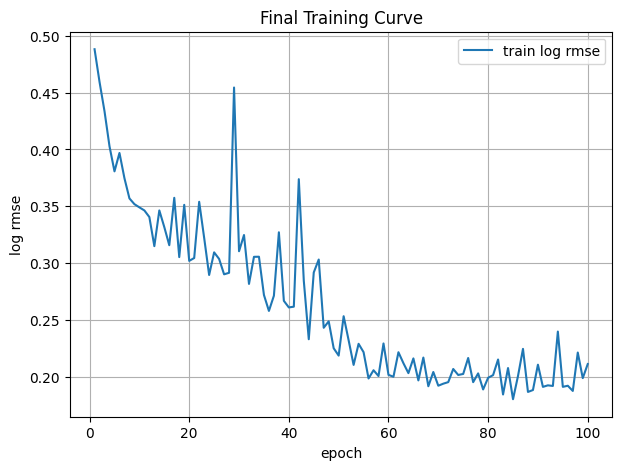

Training log rmse: 0.2113
submission.csv saved!


In [17]:
train_and_pred(
    train_features,
    test_features,
    train_labels,
    test_data,
    num_epochs,
    learning_rate,
    weight_decay,
    batch_size
)